In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit

In [2]:
                                                    # ТЕОРИЯ

In [3]:
def tune_sigma(lattice, positions, T, N, initial_sigma=np.pi/8, target=0.5, tune_steps=1000):

    sigma = initial_sigma
    for _ in range(10):  # максимум 10 итераций
        accepted = 0
        temp_lattice = lattice.copy()
        for _ in range(tune_steps):
            _, acc = metropolis_step(temp_lattice, positions, T, N, sigma)
            if acc:
                accepted += 1
        acceptance = accepted / tune_steps

        if acceptance > target + 0.05:
            sigma *= 1.1
        elif acceptance < target - 0.05:
            sigma *= 0.9
        else:
            break
    return sigma

In [4]:
def create_lattice_honeycomb(N_cells):
    n_dipoles = 2 * N_cells * N_cells
    return np.random.uniform(0, 2*np.pi, size=n_dipoles)

In [5]:
@numba.njit
def build_honeycomb_positions(N_cells, a=1.0):

    positions = []
    for i in range(N_cells):
        for j in range(N_cells):
            x = j * 1.5
            y = i * np.sqrt(3) + j*np.sqrt(3)/2
            # Подрешётка A
            positions.append([x, y])
            # Подрешётка B (сдвинута)
            positions.append([x + a/2, y + a * np.sqrt(3)/2])
    return np.array(positions)

In [6]:
@numba.njit
def honeycomb_idx_to_ij(idx, N_cells):
    total = idx // 2
    i = total // N_cells
    j = total % N_cells
    sub = idx % 2 #sublattice
    return i, j, sub

In [7]:
@numba.njit
def honeycomb_ij_to_idx(i, j, sub, N_cells):
    return (i * N_cells + j) * 2 + sub

In [8]:
def idx_to_ij(idx, N_cells): #упрощенная версия
    return honeycomb_idx_to_ij(idx, N_cells)[:2] #вот эта штука с 2 нам выкидывает третье значение sub для совместимости с кодом для квадратной решетки

In [9]:
@numba.njit
def angle_to_vector(angle):
    return np.array([np.cos(angle), np.sin(angle)])

In [10]:
@numba.njit
def get_distance_honeycomb(idx1, idx2, positions, N_cells, a=1.0):
    pos1 = positions[idx1]
    pos2 = positions[idx2]
    dx = pos2[0] - pos1[0]
    dy = pos2[1] - pos1[1]
    r = np.sqrt(dx**2 + dy**2)
    r_vec = np.array([dx, dy])
    return r_vec, r

In [11]:
@numba.njit#("UniTuple(f8[:], 2)(f8[:], i8, f8)", nopython=True, nogil=True)
#U=(p_1*p_2)/r^3 - 3(p_1*r)(p_2*r)/r^5
def pair_energy(p_1, p_2, r_vec, r):
    if r < 1e-10:
        return 0.0
    r3 = r ** 3
    r5 = r ** 5
    pp = p_1[0]*p_2[0] + p_1[1]*p_2[1]
    p_1r = p_1[0]*r_vec[0] + p_1[1]*r_vec[1]
    p_2r = p_2[0]*r_vec[0] + p_2[1]*r_vec[1]
    return pp / r3 - 3 * p_1r * p_2r / r5

In [12]:
def total_energy(lattice, positions, N_cells):
    n_dipoles = len(lattice)
    energy = 0.0
    for idx1 in range(n_dipoles):
        angle1 = lattice[idx1]
        p_1 = angle_to_vector(angle1)
        for idx2 in range(idx1 + 1, n_dipoles):
            angle2 = lattice[idx2]
            p_2 = angle_to_vector(angle2)
            r_vec, r = get_distance_honeycomb(idx1, idx2, positions, N_cells)
            energy += pair_energy(p_1, p_2, r_vec, r)
    return energy

In [13]:
def total_dipole_moment(lattice, N_cells):

    P_x = 0.0
    P_y = 0.0

    for angle in lattice:
        P_x += np.cos(angle)
        P_y += np.sin(angle)
    return np.array([P_x, P_y]), np.sqrt(P_x ** 2 + P_y ** 2)


In [14]:
def energy_change(lattice, positions, idx, new_angle, N_cells):

    old_angle = lattice[idx]
    old_p = angle_to_vector(old_angle)
    new_p = angle_to_vector(new_angle)
    delta = 0.0

    n_dipoles = len(lattice)
    for other_idx in range(n_dipoles):
        if other_idx == idx:
            continue
        other_angle = lattice[other_idx]
        other_p = angle_to_vector(other_angle)
        r_vec, r = get_distance_honeycomb(idx, other_idx, positions, N_cells)
        U_old = pair_energy(old_p, other_p, r_vec, r)
        U_new = pair_energy(new_p, other_p, r_vec, r)
        delta += (U_new - U_old)
    return delta

In [15]:
def metropolis_step(lattice, positions, T, N_cells, sigma=np.pi/10):
    beta = 1.0 / T
    n_dipoles = len(lattice)
    idx = np.random.randint(0, n_dipoles)
    old_angle = lattice[idx]
    new_angle = old_angle + np.random.normal(0, sigma)
    new_angle = new_angle % (2 * np.pi)
    delta_E = energy_change(lattice, positions, idx, new_angle, N_cells)
    if delta_E < 0:
        lattice[idx] = new_angle
        return delta_E, True
    else:
        probability = np.exp(-beta * delta_E)
        if np.random.random() < probability:
            lattice[idx] = new_angle
            return delta_E, True
        else:
            return delta_E, False

In [16]:
def monte_carlo_sweep(lattice, positions, T, N, sigma):
    accepted_count = 0
    for _ in range(N * N):
        _, is_accepted = metropolis_step(lattice, positions, T, N, sigma)
        if is_accepted:
            accepted_count += 1
    return accepted_count

In [17]:
                                #МОДЕЛИРОВАНИЕ

In [18]:
def simulate_simple(lattice, positions, T, N, sigma, mc_steps=5000, burn_in=1000):

    # Прогрев
    for _ in range(burn_in):
        monte_carlo_sweep(lattice, positions, T, N, sigma)

    history = []
    total_accepted = 0
    total_steps = 0

    for _ in range(mc_steps):
        accepted = monte_carlo_sweep(lattice, positions, T, N, sigma)
        total_accepted += accepted
        total_steps += N * N

        _, P = total_dipole_moment(lattice, N)
        P = P / (N * N)
        E = total_energy(lattice, positions, N)
        history.append((P, E))

    acceptance_rate = total_accepted / total_steps
    print(f"Частота принятия = {acceptance_rate:.2f}")

    return history

In [19]:
def simulate_multiple(N_cells, T, n_runs, mc_steps, burn_in, sigma):
    P_results = []
    E_results = []
    for run in range(n_runs):
        lattice = create_lattice_honeycomb(N_cells)
        positions = build_honeycomb_positions(N_cells)
        history = simulate_simple(lattice, positions, T, N_cells, sigma, mc_steps, burn_in)
        P_final, E_final = history[-1]
        P_results.append(P_final)
        E_results.append(E_final)
    return P_results, E_results

In [20]:
def run_fluctuations(N_cells=4, T=1.0, n_runs=4, mc_steps=100, burn_in=50, sigma=np.pi/8):
    n_dipoles = 2 * N_cells * N_cells
    print("Анализ флуктуаций (гексагональная решётка)")
    print(f"Решетка: {N_cells}×{N_cells} ячеек → {n_dipoles} диполей")
    print(f"Температура: T = {T}")
    print(f"Количество прогонов: {n_runs}")
    P_results, E_results = simulate_multiple(N_cells, T, n_runs, mc_steps, burn_in, sigma)
    print_statistics(P_results, E_results)
    plot_fluctuations(P_results, E_results, N_cells, n_dipoles, T)

In [21]:
def plot_fluctuations(P_values, E_values, N_cells, n_dipoles, T):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.hist(P_values, bins=15, edgecolor='black', alpha=0.7, color='green')
    ax1.axvline(x=np.mean(P_values), color='red', linestyle='--',
                label=f'Среднее = {np.mean(P_values):.4f}')
    ax1.set_xlabel('Конечный средний дипольный момент ⟨p⟩')
    ax1.set_ylabel('Частота')
    ax1.set_title(f'Флуктуации поляризации (гексагональная)\n({N_cells}×{N_cells} ячеек, {n_dipoles} диполей, T={T})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.hist(E_values, bins=15, edgecolor='black', alpha=0.7, color='orange')
    ax2.axvline(x=np.mean(E_values), color='red', linestyle='--',
                label=f'Среднее = {np.mean(E_values):.4f}')
    ax2.set_xlabel('Конечная энергия E')
    ax2.set_ylabel('Частота')
    ax2.set_title(f'Флуктуации энергии (гексагональная)\n({N_cells}×{N_cells} ячеек, {n_dipoles} диполей, T={T})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
def print_statistics(P_values, E_values):
    print("Статистика")
    print("\nПоляризация ⟨p⟩:")
    print(f"  Среднее = {np.mean(P_values):.4f}")
    print(f"  Стандартное отклонение = {np.std(P_values):.4f}")
    print(f"  Минимум = {np.min(P_values):.4f}")
    print(f"  Максимум = {np.max(P_values):.4f}")
    print("\nЭнергия E:")
    print(f"  Среднее = {np.mean(E_values):.4f}")
    print(f"  Стандартное отклонение = {np.std(E_values):.4f}")
    print(f"  Минимум = {np.min(E_values):.4f}")
    print(f"  Максимум = {np.max(E_values):.4f}")

In [23]:
def run_temperature_dependence(N_cells=5, temperatures=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
                                n_runs=5, mc_steps=80, burn_in=400, sigma=np.pi/8):
    n_dipoles = 2 * N_cells * N_cells
    print("Зависимость от температуры (гексагональная решётка)")
    print(f"  Решетка: {N_cells}×{N_cells} ячеек → {n_dipoles} диполей")
    print(f"  Диапазон температур: {temperatures}")
    print(f"  Прогонов на температуру: {n_runs}")
    P_means = []
    P_stds = []
    E_means = []
    E_stds = []
    sigma_values = []
    for T in temperatures:
        print(f"Температура T = {T}")
        temp_lattice = create_lattice_honeycomb(N_cells)
        positions_temp =  build_honeycomb_positions(N_cells)

        sigma_tuned = tune_sigma(temp_lattice, positions_temp, T, N_cells, initial_sigma=sigma)
        sigma_values.append(sigma_tuned)
        print(f"  Подобранная sigma = {sigma_tuned:.3f} рад ({sigma_tuned*180/np.pi:.1f}°)")
        P_vals = []
        E_vals = []
        for run in range(n_runs):
            lattice = create_lattice_honeycomb(N_cells)
            positions = build_honeycomb_positions(N_cells)
            for _ in range(burn_in):
                monte_carlo_sweep(lattice, positions, T, N_cells, sigma_tuned)
            for _ in range(mc_steps):
                monte_carlo_sweep(lattice, positions, T, N_cells, sigma_tuned)
            _, P = total_dipole_moment(lattice, N_cells)
            P = P / n_dipoles
            E = total_energy(lattice, positions, N_cells)
            P_vals.append(P)
            E_vals.append(E)
            print(f"  Прогон {run+1}/{n_runs} → ⟨p⟩ = {P:.4f}, E = {E:.4f}")
        P_means.append(np.mean(P_vals))
        P_stds.append(np.std(P_vals))
        E_means.append(np.mean(E_vals))
        E_stds.append(np.std(E_vals))
        print(f"  → Среднее ⟨p⟩ = {P_means[-1]:.4f} ± {P_stds[-1]:.4f}")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.errorbar(temperatures, P_means, yerr=P_stds, fmt='o-', capsize=5,
                     color='blue', ecolor='lightblue', markersize=8)
    ax1.set_xlabel('Температура T')
    ax1.set_ylabel('Средний дипольный момент ⟨p⟩')
    ax1.set_title('Зависимость поляризации от температуры (гексагональная)')
    ax1.grid(True, alpha=0.3)
    ax2.errorbar(temperatures, E_means, yerr=E_stds, fmt='s-', capsize=5,
                     color='green', ecolor='lightgreen', markersize=8)
    ax2.set_xlabel('Температура T')
    ax2.set_ylabel('Энергия E')
    ax2.set_title('Зависимость энергии от температуры (гексагональная)')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Итог")
    print(f"{'T':>6} | {'⟨p⟩':>12} | {'σ_p':>10} | {'E':>12} | {'σ_E':>10}")
    for i, T in enumerate(temperatures):
        print(f"{T:6.2f} | {P_means[i]:12.4f} | {P_stds[i]:10.4f} | "
                 f"{E_means[i]:12.4f} | {E_stds[i]:10.4f}")


Анализ флуктуаций (гексагональная решётка)
Решетка: 5×5 ячеек → 50 диполей
Температура: T = 1.0
Количество прогонов: 40
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.55
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.55
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.55
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.56
Частота принятия = 0.55
Частота принятия

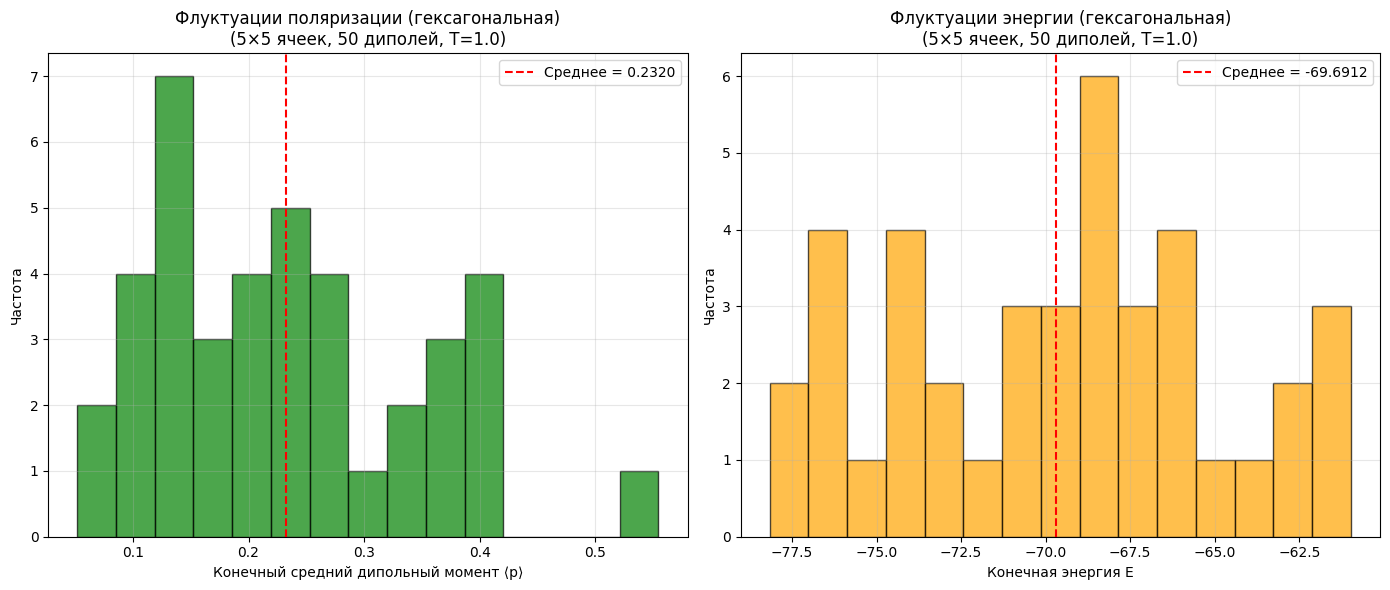

In [ ]:
if __name__ == "__main__":
    N_cells = 5
    T = 1.0
    n_runs = 40
    mc_steps = 10000
    burn_in = 2000
    sigma = np.pi/3

    run_fluctuations(N_cells, T, n_runs, mc_steps, burn_in, sigma)

In [ ]:
if __name__ == "__main__":
    N_cells = 5
    temperatures = [0.04, 0.5, 1.0, 5, 15, 40 ]
    n_runs = 40
    mc_steps = 1000
    burn_in = 200
    sigma = np.pi/8

    run_temperature_dependence(N_cells, temperatures, n_runs, mc_steps, burn_in, sigma)